# Model Comparison Report

This notebook loads the saved artifacts from the three experiment notebooks and builds summary tables and plots for the shared evaluation metrics.

In [1]:
!pip install -q pandas matplotlib seaborn

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
EXPERIMENTS = {
    "baseline_bpe": "Transformer + BPE",
    "hierarchical_whitespace": "Hierarchical + Whitespace",
    "learned_segmentation": "Hierarchical + Learned Segmentation",
}


def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


rows = []
artifacts = {}
for key, label in EXPERIMENTS.items():
    metrics_path = Path(f"{key}_metrics.json")
    config_path = Path(f"{key}_config.json")
    sample_path = Path(f"{key}_sample.txt")

    metrics = load_json(metrics_path) if metrics_path.exists() else {}
    config = load_json(config_path) if config_path.exists() else {}
    sample = sample_path.read_text(encoding="utf-8") if sample_path.exists() else ""

    artifacts[key] = {
        "label": label,
        "metrics": metrics,
        "config": config,
        "sample": sample,
    }

    rows.append(
        {
            "model_key": key,
            "model": label,
            "bpb": metrics.get("bpb"),
            "noisy_bpb": metrics.get("noisy_bpb"),
            "ood_bpb": metrics.get("ood_bpb"),
            "boundary_f1": (metrics.get("boundary_f1") or {}).get("f1"),
            "boundary_precision": (metrics.get("boundary_f1") or {}).get("precision"),
            "boundary_recall": (metrics.get("boundary_f1") or {}).get("recall"),
        }
    )

results_df = pd.DataFrame(rows)
results_df

,model_key,model,bpb,noisy_bpb,ood_bpb,boundary_f1,boundary_precision,boundary_recall
0,baseline_bpe,Transformer + BPE,0.878340,2.161368,3.835556,NaN,NaN,NaN
1,hierarchical_whitespace,Hierarchical + Whitespace,1.059831,2.226467,5.189160,1.00000,1.000000,1.000000
2,learned_segmentation,Hierarchical + Learned Segmentation,0.433457,1.180337,3.298051,0.18091,0.239748,0.145261


## Summary Table

In [4]:
summary_df = results_df.copy()
for column in ["bpb", "noisy_bpb", "ood_bpb", "boundary_f1", "boundary_precision", "boundary_recall"]:
    summary_df[column] = summary_df[column].map(lambda x: round(x, 4) if pd.notna(x) else None)
summary_df

,model_key,model,bpb,noisy_bpb,ood_bpb,boundary_f1,boundary_precision,boundary_recall
0,baseline_bpe,Transformer + BPE,0.8783,2.1614,3.8356,NaN,NaN,NaN
1,hierarchical_whitespace,Hierarchical + Whitespace,1.0598,2.2265,5.1892,1.0000,1.0000,1.0000
2,learned_segmentation,Hierarchical + Learned Segmentation,0.4335,1.1803,3.2981,0.1809,0.2397,0.1453


## Main Metrics

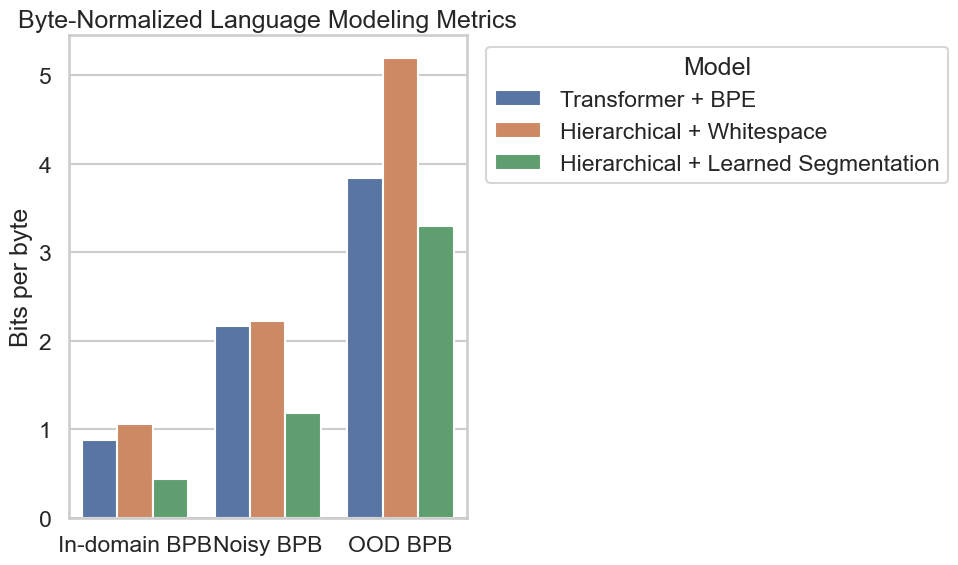

In [5]:
plot_df = results_df.melt(
    id_vars=["model"],
    value_vars=["bpb", "noisy_bpb", "ood_bpb"],
    var_name="metric",
    value_name="value",
).dropna()

metric_labels = {
    "bpb": "In-domain BPB",
    "noisy_bpb": "Noisy BPB",
    "ood_bpb": "OOD BPB",
}
plot_df["metric"] = plot_df["metric"].map(metric_labels)

ax = sns.barplot(data=plot_df, x="metric", y="value", hue="model", palette="deep")
ax.set_title("Byte-Normalized Language Modeling Metrics")
ax.set_xlabel("")
ax.set_ylabel("Bits per byte")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/var/folders/jx/wlwwdd7172j8ck50vwbpkg240000gn/T/ipykernel_3652/3803063304.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=boundary_df, x="model", y="boundary_f1", palette="crest")


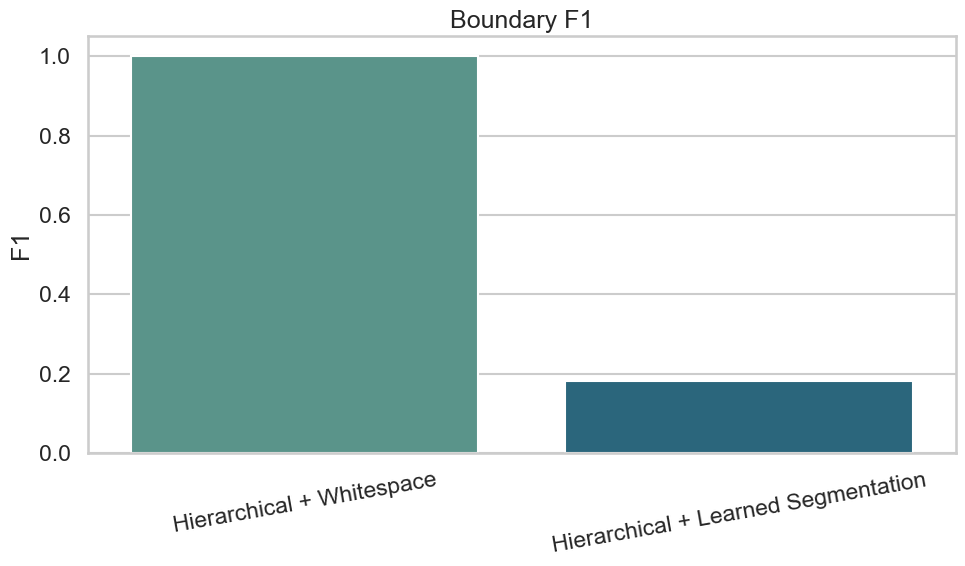

In [6]:
boundary_df = results_df.dropna(subset=["boundary_f1"])

if not boundary_df.empty:
    ax = sns.barplot(data=boundary_df, x="model", y="boundary_f1", palette="crest")
    ax.set_title("Boundary F1")
    ax.set_xlabel("")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1.05)
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()
else:
    print("Boundary metrics are not available yet.")

## Sample Generations

In [7]:
for key, artifact in artifacts.items():
    print(f"\n=== {artifact['label']} ===\n")
    print(artifact["sample"][:1200] if artifact["sample"] else "No sample saved.")


=== Transformer + BPE ===

Once upon a time , there was a little girl named Lily . She lived in a big house with her mom and daddy . They were very small and had a toy between their cheeks . Lily was so happy and she didn ' t give up . She asked her mom , " What ' s wrong , Lily ?" Lily said , " I don ' t know and you don ' t find them ." She looked around and saw a smooth ball in the forest . She nodded and said , " I am glad you have an idea . I am glad you had helped me ." Lily felt safe and helped her mom with a smile .

=== Hierarchical + Whitespace ===

Once upon a time there was a little girl named Erier. She was very excited and wanted something new. She wanted to explore the beach she harded to him. 

Sarah was very lonely and joined. She wanted to escape everything.

But Emma didn't know 

=== Hierarchical + Learned Segmentation ===

Once upon a time, then walked to hope, got home. Lily's upseting, supested, she up pillowing away around, upples!

Heything how touched Loum! 


## Paper-Ready Table

In [8]:
paper_df = summary_df[["model", "bpb", "noisy_bpb", "ood_bpb", "boundary_f1"]].copy()
paper_df.columns = ["Model", "BPB", "Noisy BPB", "OOD BPB", "Boundary F1"]
paper_df

,Model,BPB,Noisy BPB,OOD BPB,Boundary F1
0,Transformer + BPE,0.8783,2.1614,3.8356,NaN
1,Hierarchical + Whitespace,1.0598,2.2265,5.1892,1.0000
2,Hierarchical + Learned Segmentation,0.4335,1.1803,3.2981,0.1809


In [9]:
paper_df.to_csv("comparison_summary.csv", index=False)
Path("comparison_table.tex").write_text(paper_df.to_latex(index=False, na_rep="-"), encoding="utf-8")
print("Saved comparison_summary.csv and comparison_table.tex")

Saved comparison_summary.csv and comparison_table.tex
